In [7]:
# ============================================================
# NOTEBOOK 01 - ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# NPS Preditivo - Tech Challenge Fase 1 - FIAP PosTech
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [8]:
# ============================================================
# SEÇÃO 1 - CARREGAMENTO DOS DADOS
# ============================================================

# Lendo o CSV com separador
df = pd.read_csv('../data/raw/desafio_nps_fase_1.csv', sep=None, engine='python')

# Confirmando tamanho da base
print(f"Linhas:   {df.shape[0]:,}")
print(f"Colunas:  {df.shape[1]}")

# Listando todas as colunas disponíveis
print(f"\nColunas disponíveis:")
for col in df.columns:
    print(f"  - {col}")

# Primeiras linhas
print(f"\nPrimeiras 5 linhas:")
df.head()

Linhas:   2,500
Colunas:  19

Colunas disponíveis:
  - customer_id
  - customer_age
  - customer_region
  - customer_tenure_months
  - order_id
  - order_value
  - items_quantity
  - discount_value
  - payment_installments
  - delivery_time_days
  - delivery_delay_days
  - freight_value
  - delivery_attempts
  - customer_service_contacts
  - resolution_time_days
  - nps_score
  - repeat_purchase_30d
  - complaints_count
  - csat_internal_score

Primeiras 5 linhas:


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [9]:
# ============================================================
# SEÇÃO 2 - QUALIDADE DOS DADOS
# ============================================================

print("=== TIPOS DE CADA COLUNA ===")
print(df.dtypes)

print(f"\n=== VALORES NULOS ===")
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print("Nenhum valor nulo encontrado! Base completa.")
else:
    print(nulos[nulos > 0])

print(f"\n=== VALORES ÚNICOS - REGIÃO ===")
print(df['customer_region'].unique())

print(f"\n=== RANGE DO NPS SCORE ===")
print(f"Mínimo:  {df['nps_score'].min()}")
print(f"Máximo:  {df['nps_score'].max()}")
print(f"Média:   {df['nps_score'].mean():.2f}")
print(f"Mediana: {df['nps_score'].median():.2f}")

=== TIPOS DE CADA COLUNA ===
customer_id                    int64
customer_age                   int64
customer_region                  str
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

=== VALORES NULOS ===
Nenhum valor nulo encontrado! Base completa.

=== VALORES ÚNICOS - REGIÃO ===
<StringArray>
['Nordeste', 'Sul', 'Centro-Oeste', 'Norte', 'Sudeste']
Length: 5, dtype: str

=== RANGE DO NPS SCORE ===
Mínimo:  0.0
Máximo:  10.0
Média:

In [10]:
# ============================================================
# SEÇÃO 3 - CRIAÇÃO DA VARIÁVEL TARGET
# ============================================================

# Função de classificação seguindo metodologia oficial do NPS
def aplicar_nps_categoria(score):
    if score <= 6:
        return 'Detrator'
    elif score <= 8:
        return 'Neutro'
    else:
        return 'Promotor'

# Aplicando a classificação
df['nps_categoria'] = df['nps_score'].apply(aplicar_nps_categoria)

# Ordem lógica para os gráficos
ordem = ['Detrator', 'Neutro', 'Promotor']
cores = {'Detrator': '#E24B4A', 'Neutro': '#EF9F27', 'Promotor': '#1D9E75'}

# Resultado
print("=== DISTRIBUIÇÃO DA TARGET ===")
contagem = df['nps_categoria'].value_counts()[ordem]
proporcao = df['nps_categoria'].value_counts(normalize=True)[ordem] * 100

for cat in ordem:
    print(f"{cat:10s} → {contagem[cat]:>5} clientes ({proporcao[cat]:.1f}%)")

print(f"\nTotal: {len(df):,} clientes")
print(f"\n Base desbalanceada — detratores dominam ({proporcao['Detrator']:.1f}%)")
print(f"   Isso exigirá técnicas especiais no modelo preditivo (Sprint 4)")

=== DISTRIBUIÇÃO DA TARGET ===
Detrator   →  1851 clientes (74.0%)
Neutro     →   448 clientes (17.9%)
Promotor   →   201 clientes (8.0%)

Total: 2,500 clientes

 Base desbalanceada — detratores dominam (74.0%)
   Isso exigirá técnicas especiais no modelo preditivo (Sprint 4)


In [13]:
# ============================================================
# SEÇÃO 4 - CORRELAÇÕES COM O NPS
# ============================================================

# Selecionando apenas colunas numéricas
# Excluindo IDs (não têm valor analítico) e csat (data leakage)
colunas_excluir = ['customer_id', 'order_id', 'csat_internal_score']
colunas_analise = [c for c in df.select_dtypes(include=np.number).columns
                   if c not in colunas_excluir]

# Calculando correlação de todas as variáveis com nps_score
correlacoes = (df[colunas_analise]
               .corr()['nps_score']
               .drop('nps_score')
               .sort_values())

print("=== CORRELAÇÃO DAS VARIÁVEIS COM NPS SCORE ===")
print("(valores próximos de -1 ou +1 indicam relação forte)\n")

for var, corr in correlacoes.items():
    # Barra visual de correlação
    barra = '█' * int(abs(corr) * 20)
    sinal = '-' if corr < 0 else '+'
    forca = 'FORTE' if abs(corr) > 0.5 else 'MODERADA' if abs(corr) > 0.3 else 'FRACA'
    print(f"{var:<35} {sinal}{abs(corr):.3f}  {barra} {forca}")

print(f"\n'csat_internal_score' foi excluído — data leakage confirmado")
print(f"   Correlação original com nps_score era: "
      f"{df['csat_internal_score'].corr(df['nps_score']):.3f}")

=== CORRELAÇÃO DAS VARIÁVEIS COM NPS SCORE ===
(valores próximos de -1 ou +1 indicam relação forte)

delivery_delay_days                 -0.597  ███████████ FORTE
complaints_count                    -0.497  █████████ MODERADA
customer_service_contacts           -0.351  ███████ MODERADA
resolution_time_days                -0.191  ███ FRACA
freight_value                       -0.041   FRACA
customer_age                        -0.010   FRACA
customer_tenure_months              -0.010   FRACA
delivery_time_days                  +0.001   FRACA
items_quantity                      +0.011   FRACA
payment_installments                +0.024   FRACA
discount_value                      +0.025   FRACA
delivery_attempts                   +0.028   FRACA
order_value                         +0.037   FRACA
repeat_purchase_30d                 +0.570  ███████████ FORTE

'csat_internal_score' foi excluído — data leakage confirmado
   Correlação original com nps_score era: 0.564


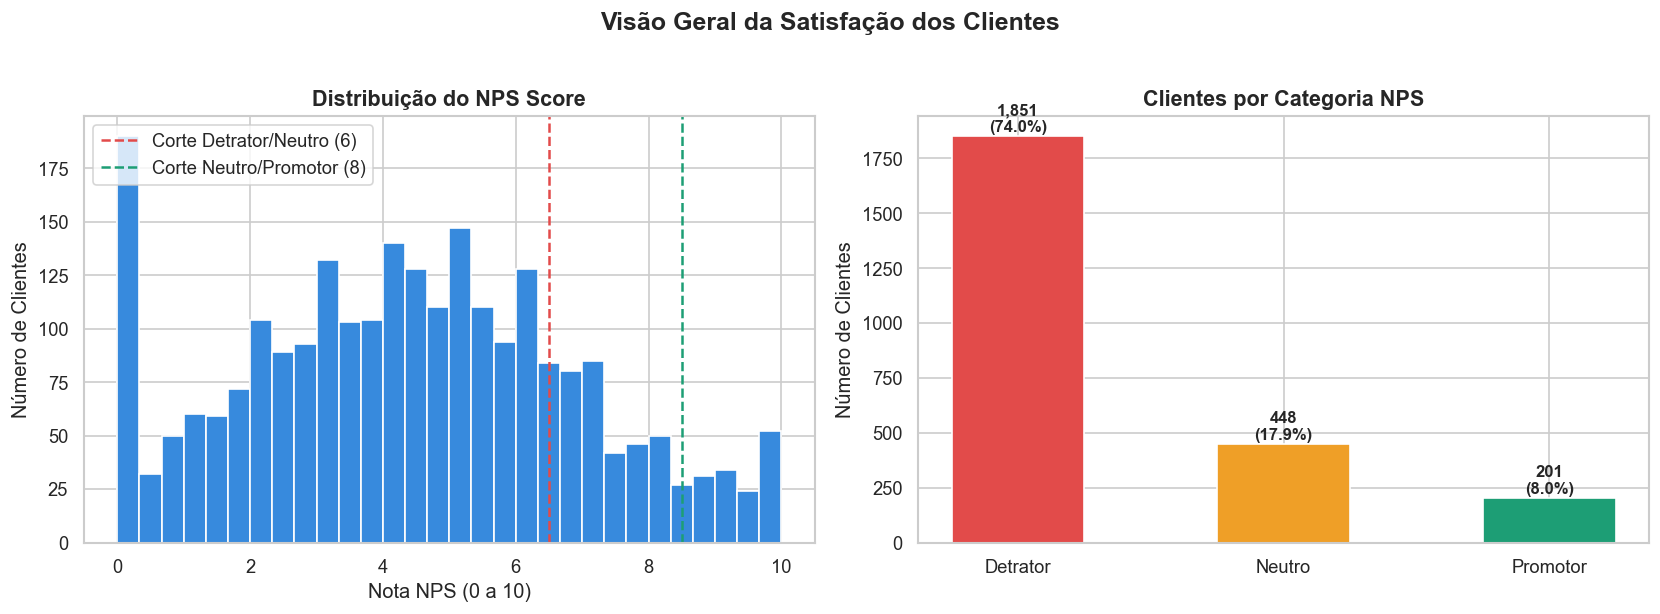

Gráfico salvo em reports/figures/


In [14]:
# ============================================================
# SEÇÃO 5 - DISTRIBUIÇÃO DO NPS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Histograma do NPS contínuo ---
axes[0].hist(df['nps_score'], bins=30, color='#378ADD', edgecolor='white')
axes[0].axvline(6.5, color='#E24B4A', linestyle='--',
                linewidth=1.5, label='Corte Detrator/Neutro (6)')
axes[0].axvline(8.5, color='#1D9E75', linestyle='--',
                linewidth=1.5, label='Corte Neutro/Promotor (8)')
axes[0].set_title('Distribuição do NPS Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nota NPS (0 a 10)')
axes[0].set_ylabel('Número de Clientes')
axes[0].legend()

# --- Gráfico 2: Barras por categoria ---
contagem = df['nps_categoria'].value_counts()[ordem]
bars = axes[1].bar(ordem, contagem,
                   color=[cores[c] for c in ordem],
                   edgecolor='white', width=0.5)
axes[1].set_title('Clientes por Categoria NPS', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Número de Clientes')

# Adicionando rótulos nas barras
for bar, val in zip(bars, contagem):
    pct = val / len(df) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f'{val:,}\n({pct:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Visão Geral da Satisfação dos Clientes',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/01_distribuicao_nps.png', bbox_inches='tight')
plt.show()
print("Gráfico salvo em reports/figures/")

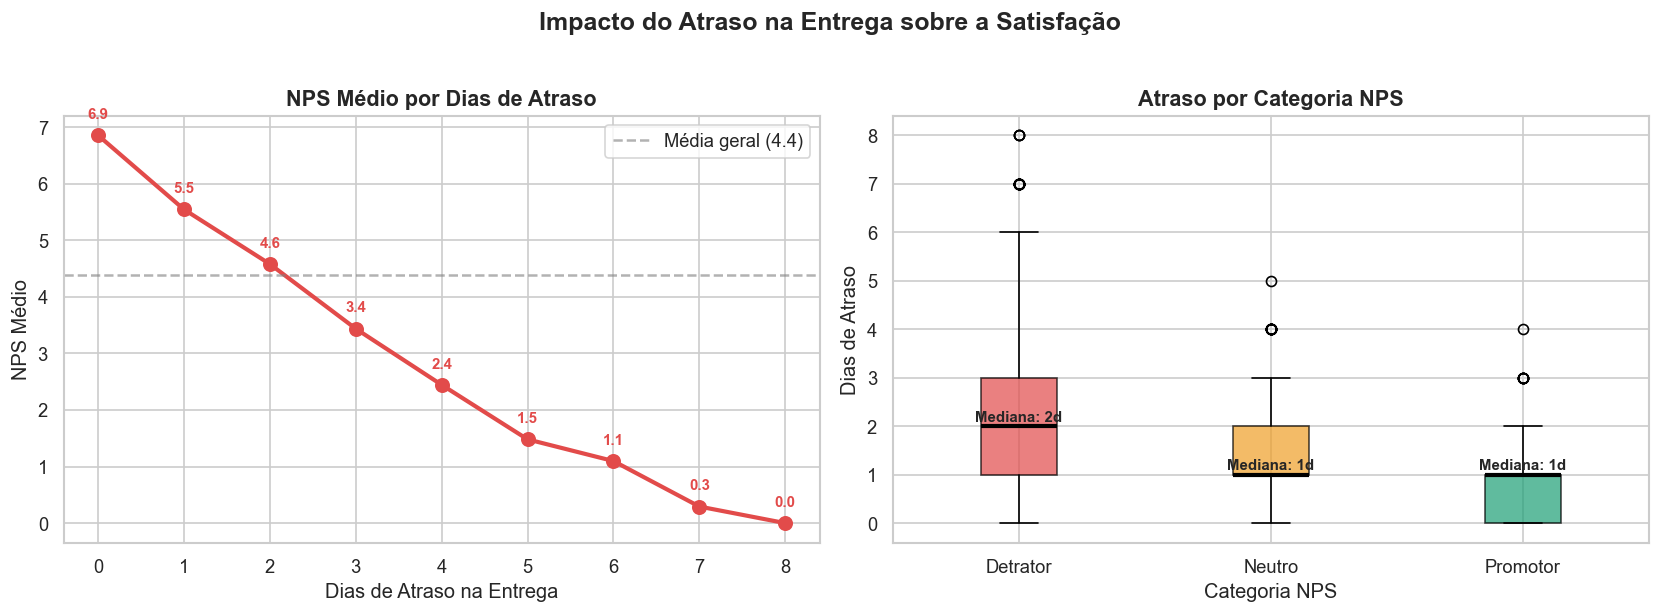

=== INSIGHT: NPS MÉDIO POR DIAS DE ATRASO ===
  0 dia(s) → NPS médio: 6.9 → Neutro
  1 dia(s) → NPS médio: 5.5 → Detrator
  2 dia(s) → NPS médio: 4.6 → Detrator
  3 dia(s) → NPS médio: 3.4 → Detrator
  4 dia(s) → NPS médio: 2.4 → Detrator
  5 dia(s) → NPS médio: 1.5 → Detrator
  6 dia(s) → NPS médio: 1.1 → Detrator
  7 dia(s) → NPS médio: 0.3 → Detrator
  8 dia(s) → NPS médio: 0.0 → Detrator

=== PONTO DE RUPTURA ===
  Maior queda no NPS ocorre em: 1 dias de atraso
  → Recomendação: SLA logístico deve garantir atraso máximo de 0 dia(s)


In [15]:
# ============================================================
# SEÇÃO 6 - ATRASO NA ENTREGA vs NPS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: NPS médio por dias de atraso ---
nps_por_atraso = (df.groupby('delivery_delay_days')['nps_score']
                  .mean()
                  .reset_index())

axes[0].plot(nps_por_atraso['delivery_delay_days'],
             nps_por_atraso['nps_score'],
             marker='o', color='#E24B4A', linewidth=2.5, markersize=8)

media_geral = df['nps_score'].mean()
axes[0].axhline(media_geral, color='gray', linestyle='--',
                alpha=0.6, label=f'Média geral ({media_geral:.1f})')

for _, row in nps_por_atraso.iterrows():
    axes[0].annotate(f"{row['nps_score']:.1f}",
                     (row['delivery_delay_days'], row['nps_score']),
                     textcoords="offset points", xytext=(0, 10),
                     ha='center', fontsize=9,
                     color='#E24B4A', fontweight='bold')

axes[0].set_title('NPS Médio por Dias de Atraso', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Dias de Atraso na Entrega')
axes[0].set_ylabel('NPS Médio')
axes[0].set_xticks(nps_por_atraso['delivery_delay_days'])
axes[0].legend()

# --- Gráfico 2: Boxplot por categoria ---
dados_box = [df[df['nps_categoria'] == cat]['delivery_delay_days'].values
             for cat in ordem]

bp = axes[1].boxplot(dados_box, labels=ordem, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2.5))

for patch, cat in zip(bp['boxes'], ordem):
    patch.set_facecolor(cores[cat])
    patch.set_alpha(0.7)

# Adicionando medianas como texto
for i, cat in enumerate(ordem):
    mediana = df[df['nps_categoria'] == cat]['delivery_delay_days'].median()
    axes[1].text(i + 1, mediana + 0.1, f'Mediana: {mediana:.0f}d',
                 ha='center', fontsize=9, fontweight='bold')

axes[1].set_title('Atraso por Categoria NPS', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Categoria NPS')
axes[1].set_ylabel('Dias de Atraso')

plt.suptitle('Impacto do Atraso na Entrega sobre a Satisfação',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/03_atraso_entrega.png', bbox_inches='tight')
plt.show()

# Insights numéricos
print("=== INSIGHT: NPS MÉDIO POR DIAS DE ATRASO ===")
for _, row in nps_por_atraso.iterrows():
    cat = aplicar_nps_categoria(row['nps_score'])
    emoji = '🔴' if cat == 'Detrator' else '🟡' if cat == 'Neutro' else '🟢'
    print(f"  {int(row['delivery_delay_days'])} dia(s) → "
          f"NPS médio: {row['nps_score']:.1f} → {cat}")

print(f"\n=== PONTO DE RUPTURA ===")
queda_maxima = nps_por_atraso['nps_score'].diff().idxmin()
dia_ruptura = nps_por_atraso.loc[queda_maxima, 'delivery_delay_days']
print(f"  Maior queda no NPS ocorre em: {int(dia_ruptura)} dias de atraso")
print(f"  → Recomendação: SLA logístico deve garantir atraso máximo de "
      f"{int(dia_ruptura)-1} dia(s)")